<a href="https://colab.research.google.com/github/Akspaks007/DL-Lab/blob/main/Exp_7/Exp_7_SentimentAnalysisRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Data

In [ ]:
import csv
import re
import numpy as np

# 1. Manual CSV Loader (No Pandas allowed)
def load_imdb_csv(file_path):
    texts = []
    labels = []

    with open(file_path, 'r', encoding='utf-8') as f:
        # csv.reader handles quotes and commas in movie reviews automatically
        reader = csv.reader(f)
        next(reader)  # Skip header: "review,sentiment"

        for row in reader:
            if len(row) == 2:
                texts.append(row[0])
                # Mapping: 'positive' -> 1, 'negative' -> 0
                labels.append(1 if row[1].lower() == 'positive' else 0)

    return texts, labels

# 2. Manual Text Cleaning & Tokenization
def clean_string(text):
    # Standardize to lowercase and remove non-alphanumeric chars
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()

# 3. Manual Vocabulary Builder
def build_vocab(data, max_vocab=5000):
    word_counts = {}
    for text in data:
        for word in clean_string(text):
            word_counts[word] = word_counts.get(word, 0) + 1

    # Sort by frequency to keep only the most important words
    sorted_vocab = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
    vocab = {word: i+2 for i, (word, _) in enumerate(sorted_vocab[:max_vocab])}
    vocab["<PAD>"], vocab["<UNK>"] = 0, 1
    return vocab

# 4. Sequence Processor (Numericalization + Padding)
def text_to_sequences(data, vocab, max_len=100):
    sequences = []
    for text in data:
        tokens = clean_string(text)
        # Convert words to IDs; use 1 (<UNK>) if word isn't in vocab
        ids = [vocab.get(word, 1) for word in tokens][:max_len]
        # Manual Padding with 0 (<PAD>) to ensure fixed length arrays
        ids += [0] * (max_len - len(ids))
        sequences.append(ids)
    return np.array(sequences)

# --- EXECUTION ---
csv_path = '/content/IMDB Dataset.csv'

print("Loading IMDB CSV Data...")
raw_texts, raw_labels = load_imdb_csv(csv_path)

# Manual 80/20 Train/Test Split
split_idx = int(len(raw_texts) * 0.8)
raw_train_texts = raw_texts[:split_idx]
train_labels = raw_labels[:split_idx]
raw_test_texts = raw_texts[split_idx:]
test_labels = raw_labels[split_idx:]

print(f"Loaded {len(raw_train_texts)} Training and {len(raw_test_texts)} Test samples.")

# Process Data
vocab = build_vocab(raw_train_texts, max_vocab=5000)
X_train = text_to_sequences(raw_train_texts, vocab, max_len=100)
y_train = np.array(train_labels).reshape(-1, 1)

X_test = text_to_sequences(raw_test_texts, vocab, max_len=100)
y_test = np.array(test_labels).reshape(-1, 1)

# --- DATA DESCRIPTION & VALIDATION ---
print("\n--- Data Description ---")
print(f"X_train Shape: {X_train.shape} (Samples, Sequence_Length)")
print(f"y_train Shape: {y_train.shape}")
print(f"Vocab Size: {len(vocab)}")

# Show a decoded sample to verify it exists and is valid
rev_vocab = {v: k for k, v in vocab.items()}
sample_decoded = " ".join([rev_vocab.get(i, '<UNK>') for i in X_train[0][:15]])
print(f"\nSample 1 Label: {y_train[0][0]} (1=Pos, 0=Neg)")
print(f"Sample 1 Decoded: {sample_decoded}...")

Loading IMDB CSV Data...
Loaded 40000 Training and 10000 Test samples.

--- Data Description ---
X_train Shape: (40000, 100) (Samples, Sequence_Length)
y_train Shape: (40000, 1)
Vocab Size: 5002

Sample 1 Label: 1 (1=Pos, 0=Neg)
Sample 1 Decoded: one of the other reviewers has mentioned that after watching just 1 oz episode youll...


RNN Class

In [ ]:
class NumPyRNN:
    def __init__(self, vocab_size, hidden_size, embed_size=None, lr=0.01):
        self.lr = lr
        self.h_size = hidden_size
        self.vocab_size = vocab_size
        self.use_embed = embed_size is not None

        # Input Layer Setup
        input_dim = embed_size if self.use_embed else vocab_size
        if self.use_embed:
            self.E = np.random.randn(vocab_size, embed_size) * 0.01

        # RNN Weights (Xavier Initialization)
        self.Wxh = np.random.randn(hidden_size, input_dim) * np.sqrt(1./input_dim)
        self.Whh = np.random.randn(hidden_size, hidden_size) * np.sqrt(1./hidden_size)
        self.Why = np.random.randn(1, hidden_size) * np.sqrt(1./hidden_size)
        self.bh, self.by = np.zeros((hidden_size, 1)), np.zeros((1, 1))

    def forward(self, x_indices):
        self.hs = {-1: np.zeros((self.h_size, 1))}
        self.xs = {}
        T = len(x_indices)

        for t in range(T):
            idx = x_indices[t]
            if self.use_embed:
                self.xs[t] = self.E[idx:idx+1, :].T # Dense vector
            else:
                xt = np.zeros((self.vocab_size, 1))
                xt[idx] = 1 # Sparse One-Hot vector
                self.xs[t] = xt

            # h_t = tanh(Wxh*xt + Whh*ht-1 + bh)
            z = np.dot(self.Wxh, self.xs[t]) + np.dot(self.Whh, self.hs[t-1]) + self.bh
            self.hs[t] = np.tanh(z)

        y = np.dot(self.Why, self.hs[T-1]) + self.by
        return 1 / (1 + np.exp(-y)) # Sigmoid Output

    def backward(self, x_indices, target, prob):
        T = len(x_indices)
        dy = prob - target
        dWhy = np.dot(dy, self.hs[T-1].T)
        dby = dy

        dh = np.dot(self.Why.T, dy)
        dWxh, dWhh, dbh = 0, 0, 0
        if self.use_embed: dE = np.zeros_like(self.E)

        # Backpropagation Through Time (BPTT)
        for t in reversed(range(T)):
            dtanh = (1 - self.hs[t]**2) * dh
            dbh += dtanh
            dWxh += np.dot(dtanh, self.xs[t].T)
            dWhh += np.dot(dtanh, self.hs[t-1].T)

            if self.use_embed:
                dE[x_indices[t]] += np.dot(self.Wxh.T, dtanh).flatten()

            dh = np.dot(self.Whh.T, dtanh)

        # Gradient Updates
        for p, g in zip([self.Wxh, self.Whh, self.Why, self.bh, self.by],
                        [dWxh, dWhh, dWhy, dbh, dby]):
            p -= self.lr * np.clip(g, -5, 5) # Clipping to prevent exploding gradients
        if self.use_embed: self.E -= self.lr * np.clip(dE, -5, 5)

Implementation

Training One-Hot RNN...
Epoch 1/5 | Avg Loss: 0.6963
Epoch 2/5 | Avg Loss: 0.6948
Epoch 3/5 | Avg Loss: 0.6943
Epoch 4/5 | Avg Loss: 0.6949
Epoch 5/5 | Avg Loss: 0.6938
Training Embedding RNN...
Epoch 1/5 | Avg Loss: 0.6997
Epoch 2/5 | Avg Loss: 0.6945
Epoch 3/5 | Avg Loss: 0.6941
Epoch 4/5 | Avg Loss: 0.6940
Epoch 5/5 | Avg Loss: 0.6939


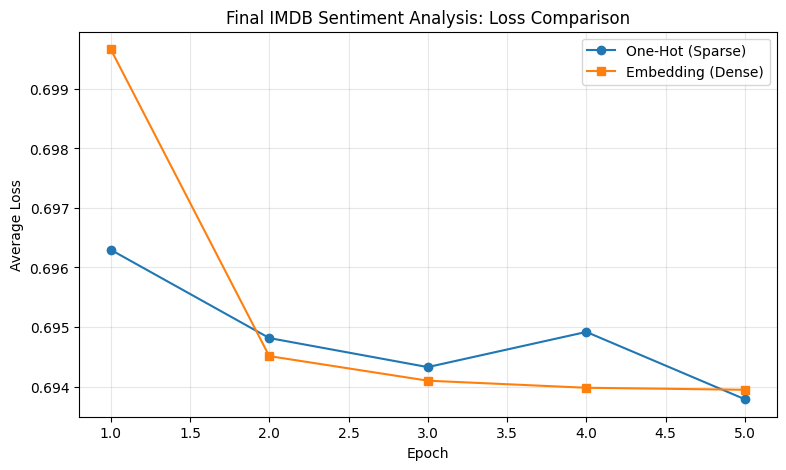

In [ ]:
import matplotlib.pyplot as plt

def train_and_log_final(model, name, epochs=5):
    print(f"Training {name}...")
    losses = []

    # Use a larger subset now that we have the full CSV loaded
    total_available = len(X_train)
    num_samples = min(5000, total_available)
    indices = np.arange(total_available)

    for epoch in range(epochs):
        np.random.shuffle(indices)
        epoch_loss = 0

        for i in range(num_samples):
            idx = indices[i]
            x_seq = X_train[idx]
            y_true = y_train[idx]

            # Forward Pass
            prob = model.forward(x_seq)

            # Binary Cross Entropy Loss
            loss = -(y_true * np.log(prob + 1e-8) + (1 - y_true) * np.log(1 - prob + 1e-8))

            # Backward Pass (Now with clipping inside the class method)
            model.backward(x_seq, y_true, prob)

            epoch_loss += loss

        avg_loss = epoch_loss / num_samples
        losses.append(avg_loss[0][0])
        print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss[0][0]:.4f}")

    return losses

# --- Run Experiments with Lower Learning Rate ---

# 1. One-Hot RNN (Sparse)
rnn_onehot = NumPyRNN(vocab_size=len(vocab), hidden_size=32, embed_size=None, lr=0.001)
one_hot_final = train_and_log_final(rnn_onehot, "One-Hot RNN")

# 2. Embedding RNN (Dense)
rnn_embed = NumPyRNN(vocab_size=len(vocab), hidden_size=32, embed_size=16, lr=0.001)
embed_final = train_and_log_final(rnn_embed, "Embedding RNN")

# --- Final Comparison Plot ---
plt.figure(figsize=(9, 5))
plt.plot(range(1, 6), one_hot_final, 'o-', label='One-Hot (Sparse)')
plt.plot(range(1, 6), embed_final, 's-', label='Embedding (Dense)')
plt.title('Final IMDB Sentiment Analysis: Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()